## Introduction


### Dataset
The dataset used for this analysis is the "Fake News Classification" dataset from Kaggle. It contains news articles labeled as "fake" or "real". The dataset includes the following columns:
- `id`: Unique identifier for each news article
- `title`: The title of the news article
- `text`: The full text of the news article
- `label`: The label indicating whether the news is "fake" (0) or "real" (1)

### Objective
The objective of this analysis is to build a machine learning model that can classify news articles as fake or real based on their content.
We will perform the following steps:
1. Data Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Building
5. Model Evaluation
6. Conclusion

In [ ]:
import nltk
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import sparse
import joblib

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import pandas as pd

from spellchecker import SpellChecker
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import lightgbm as lgb

import shap
import matplotlib.pyplot as plt


c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Analysis and Preprocessing

In [5]:
df = pd.read_csv("WELFake_Dataset.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [7]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


Class distribution

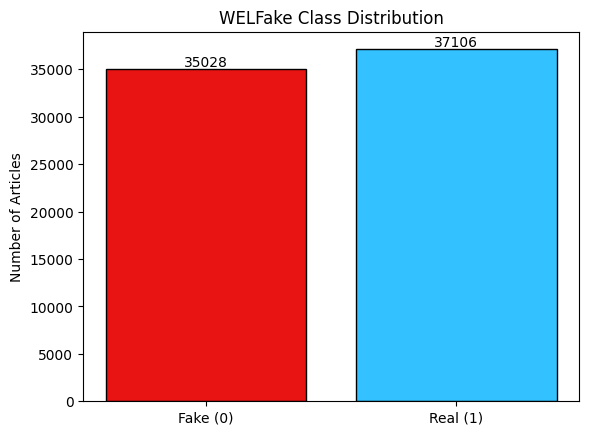

In [14]:
counts = df['label'].value_counts().sort_index()

labels = ['Fake (0)', 'Real (1)']
values = [counts.get(0, 0), counts.get(1, 0)]

colors = ["#E81313", '#33C1FF']

# Plot
plt.figure()
bars = plt.bar(labels, values, color=colors, edgecolor='black')

# title and labels
plt.title('WELFake Class Distribution')
plt.ylabel('Number of Articles')

# Add value labels on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.show()

In [ ]:
df.isnull().sum()

Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

Text length statistics

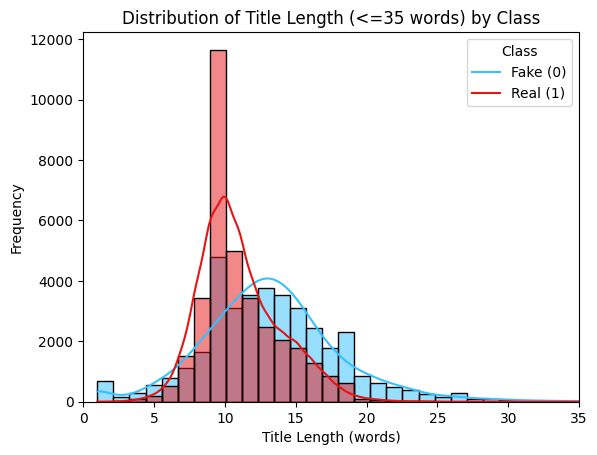

In [44]:
# title length
df['title_length'] = df['title'].apply(lambda x: len(str(x).split()))

plt.figure()
sns.histplot(data=df[df['title_length']<=35], x='title_length', hue='label', bins=30, kde=True, kde_kws={'bw_adjust': 1.5}, palette=colors)
plt.title('Distribution of Title Length (<=35 words) by Class')
plt.xlabel('Title Length (words)')
plt.ylabel('Frequency')
plt.xlim(0, 35)
plt.legend(title='Class', labels=['Fake (0)', 'Real (1)'])
plt.show()

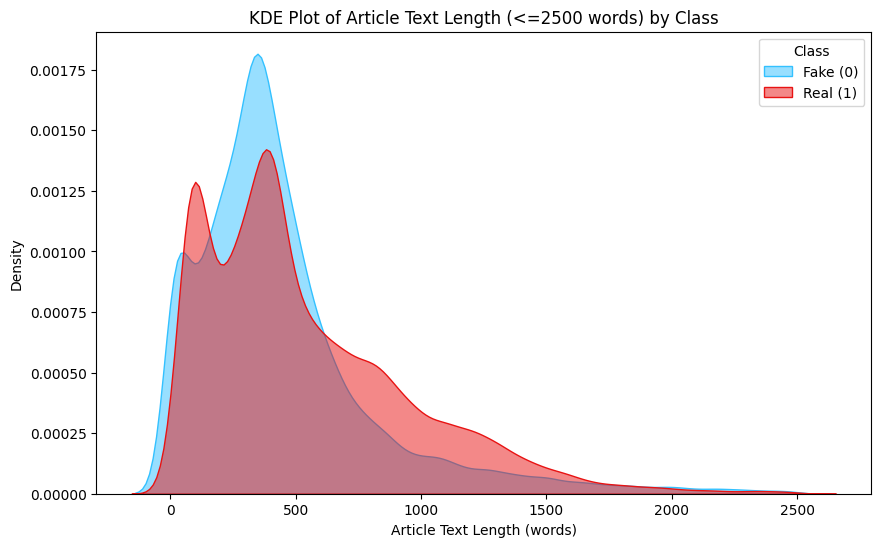

In [ ]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['text_length']<=2500], x='text_length', hue='label', fill=True, common_norm=False, palette=colors, alpha=0.5)
plt.title('KDE Plot of Article Text Length (<=2500 words) by Class')
plt.xlabel('Article Text Length (words)')
plt.ylabel('Density')
plt.legend(title='Class', labels=['Fake (0)', 'Real (1)'])
plt.show()


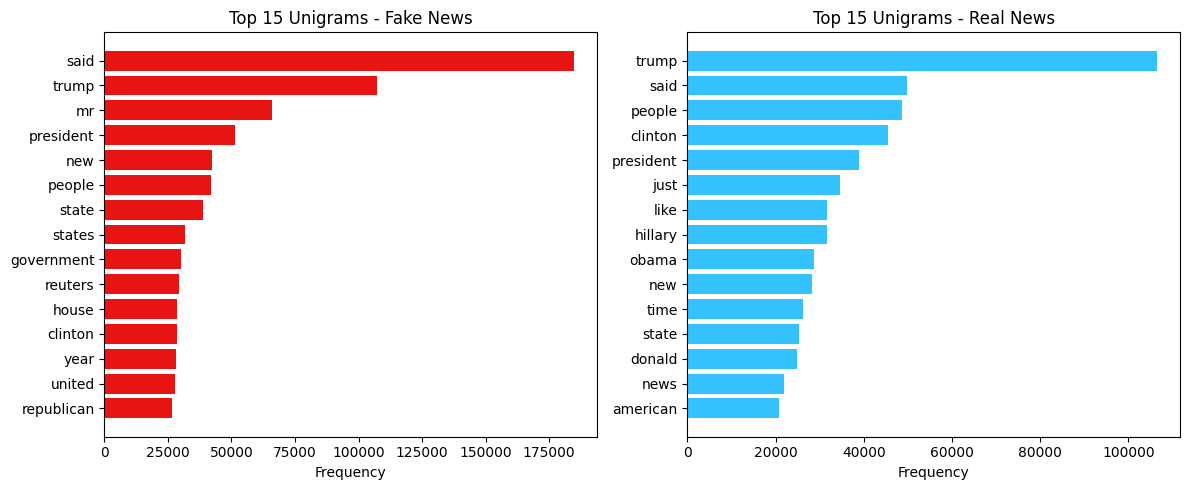

In [ ]:
fake_texts = df[df['label'] == 0]['text'].astype(str)
real_texts = df[df['label'] == 1]['text'].astype(str)

# fake unigrams
vectorizer = CountVectorizer(stop_words='english')

fake_matrix = vectorizer.fit_transform(fake_texts)
fake_counts = fake_matrix.sum(axis=0).A1
fake_vocab = vectorizer.get_feature_names_out()

fake_freq = pd.DataFrame({'word': fake_vocab, 'freq': fake_counts})
fake_top = fake_freq.sort_values(by='freq', ascending=False).head(15)

# real unigrams
vectorizer = CountVectorizer(stop_words='english')
real_matrix = vectorizer.fit_transform(real_texts)
real_counts = real_matrix.sum(axis=0).A1
real_vocab = vectorizer.get_feature_names_out()

real_freq = pd.DataFrame({'word': real_vocab, 'freq': real_counts})
real_top = real_freq.sort_values(by='freq', ascending=False).head(15)

# plot
plt.figure(figsize=(12,5))

# fake
plt.subplot(1,2,1)
plt.barh(fake_top['word'][::-1], fake_top['freq'][::-1], color='#E81313')
plt.title('Top 15 Unigrams - Fake News')
plt.xlabel('Frequency')

# real
plt.subplot(1,2,2)
plt.barh(real_top['word'][::-1], real_top['freq'][::-1], color='#33C1FF')
plt.title('Top 15 Unigrams - Real News')
plt.xlabel('Frequency')

plt.tight_layout()
plt.show()

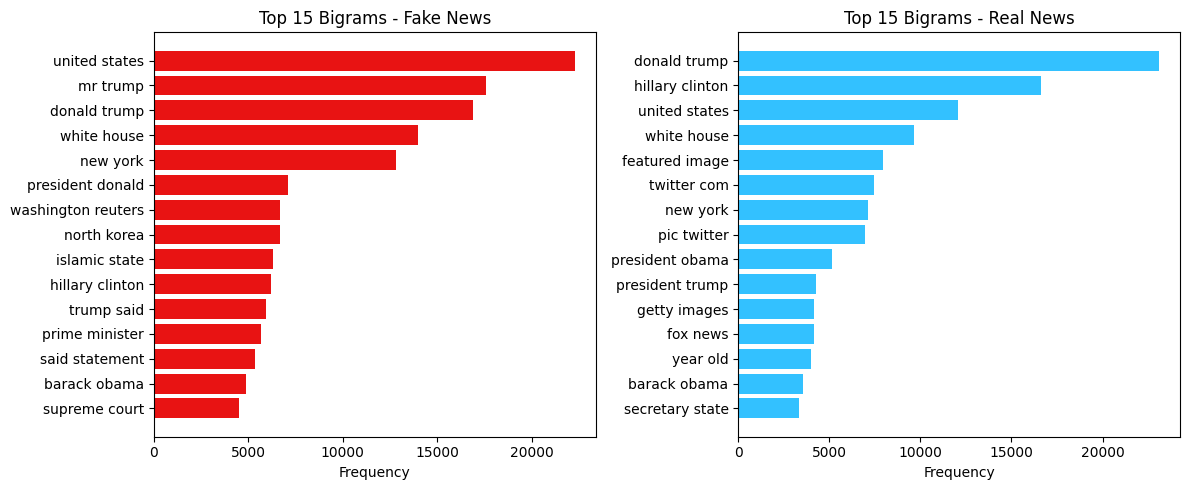

In [ ]:
fake_texts = df[df['label'] == 0]['text'].astype(str)
real_texts = df[df['label'] == 1]['text'].astype(str)


# fake bigrams
vectorizer = CountVectorizer(stop_words='english', ngram_range=(2, 2))
fake_matrix = vectorizer.fit_transform(fake_texts)

fake_counts = fake_matrix.sum(axis=0).A1
fake_vocab = vectorizer.get_feature_names_out()

fake_freq = pd.DataFrame({'bigram': fake_vocab, 'freq': fake_counts})
fake_top = fake_freq.sort_values(by='freq', ascending=False).head(15)


# real bigrams
vectorizer = CountVectorizer(stop_words='english', ngram_range=(2, 2))
real_matrix = vectorizer.fit_transform(real_texts)

real_counts = real_matrix.sum(axis=0).A1
real_vocab = vectorizer.get_feature_names_out()

real_freq = pd.DataFrame({'bigram': real_vocab, 'freq': real_counts})
real_top = real_freq.sort_values(by='freq', ascending=False).head(15)

# plot
plt.figure(figsize=(12,5))

# fake
plt.subplot(1,2,1)
plt.barh(fake_top['bigram'][::-1], fake_top['freq'][::-1], color='#E81313')
plt.title('Top 15 Bigrams - Fake News')
plt.xlabel('Frequency')

# real
plt.subplot(1,2,2)
plt.barh(real_top['bigram'][::-1], real_top['freq'][::-1], color='#33C1FF')
plt.title('Top 15 Bigrams - Real News')
plt.xlabel('Frequency')

plt.tight_layout()
plt.show()

In [56]:
df = df[['title', 'text', 'label']]

In [58]:
# remove data with text null
df = df[["title", "text", "label"]].dropna(subset=['text'])
# substitue null values with "" in title column
df['title'] = df['title'].fillna("")

### Stylometric Feature Engineering
This section focuses on extracting stylometric features from the news articles to enhance the model's ability to distinguish between fake and real news. Stylometric features are derived from the writing style of the text and can provide insights into the authenticity of the news articles.
These features include:
- Length of the article's body (character)
- Average number of exclamation and question marks in the article's body
- Average number of uppercase words in the article's title
- Average number of exclamation and question marks in the article's title
- Count of exclamation and question marks in the article's body


In [62]:
# add column with the length of the text
df['text_length'] = df['text'].apply(len)
# add column with ratio of exclamation point and question mark in the text
df['text_exclamation_ratio'] = df['text'].apply(lambda x: (x.count('!') + x.count('?')) / len(x) if len(x) > 0 else 0)
# add column with uppercase chars ratio in the title
df['title_uppercase_ratio'] = df['title'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)
# add column with ratio of exclamation point and question mark in the title
df['title_exclamation_ratio'] = df['title'].apply(lambda x: (x.count('!') + x.count('?')) / len(x) if len(x) > 0 else 0)
# add column with sum of exclamation point and question mark in the text
df['text_exclamation_count'] = df['text'].apply(lambda x: x.count('!') + x.count('?'))

C:\Users\Advancia\AppData\Local\Temp\ipykernel_22504\2182510797.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='text_exclamation_ratio', palette=colors)


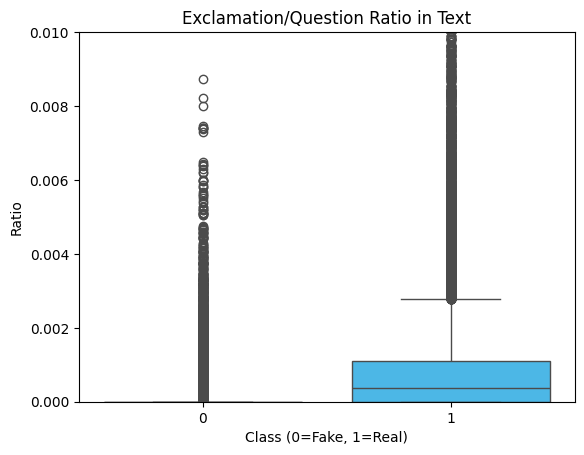

In [83]:
plt.figure()
sns.boxplot(data=df, x='label', y='text_exclamation_ratio', palette=colors)

plt.title('Exclamation/Question Ratio in Text')
plt.xlabel('Class (0=Fake, 1=Real)')
plt.ylabel('Ratio')
plt.ylim(0, 0.01)  # Limit y-axis to focus on typical range

plt.show()

C:\Users\Advancia\AppData\Local\Temp\ipykernel_22504\668407410.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='text_exclamation_count', palette=colors)


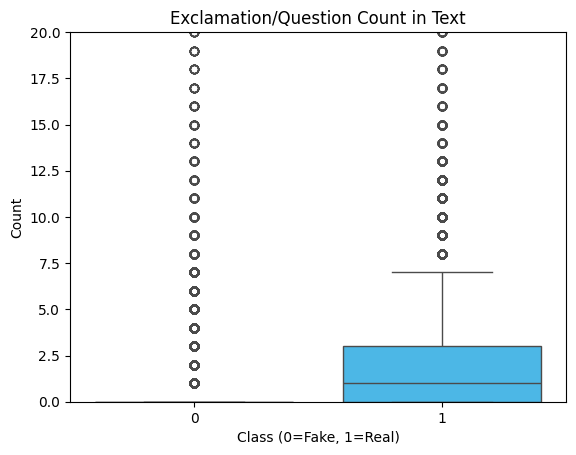

In [78]:
plt.figure()
sns.boxplot(data=df, x='label', y='text_exclamation_count', palette=colors)

plt.title('Exclamation/Question Count in Text')
plt.xlabel('Class (0=Fake, 1=Real)')
plt.ylabel('Count')
plt.ylim(0, 20)  # Limit y-axis to focus on typical range

plt.show()

C:\Users\Advancia\AppData\Local\Temp\ipykernel_22504\3980323974.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='title_uppercase_ratio', palette=colors)


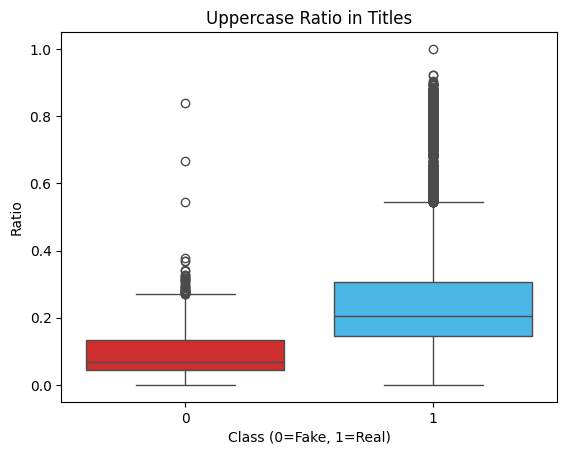

In [80]:
plt.figure()
sns.boxplot(data=df, x='label', y='title_uppercase_ratio', palette=colors)

plt.title('Uppercase Ratio in Titles')
plt.xlabel('Class (0=Fake, 1=Real)')
plt.ylabel('Ratio')

plt.show()

C:\Users\Advancia\AppData\Local\Temp\ipykernel_22504\969295750.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='title_exclamation_ratio', palette=colors)


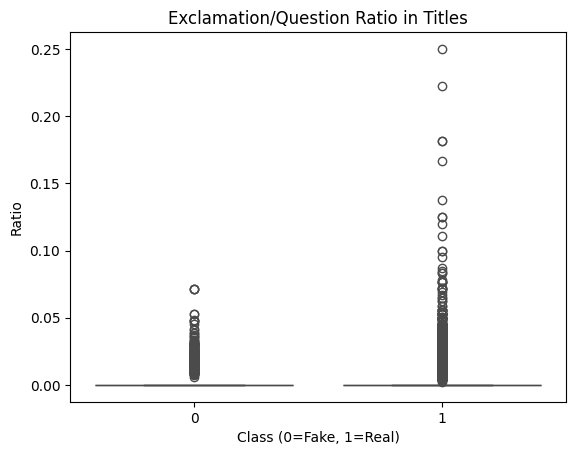

In [88]:
plt.figure()
sns.boxplot(data=df, x='label', y='title_exclamation_ratio', palette=colors)

plt.title('Exclamation/Question Ratio in Titles')
plt.xlabel('Class (0=Fake, 1=Real)')
plt.ylabel('Ratio')

plt.show()

Here we create a new feature called `full_text` by concatenating the `title` and `text` columns. This allows us to analyze the combined content of the news articles for further feature extraction and analysis.

In [ ]:
df['full_text'] = df['title'] + " " + df['text']

In [90]:
df.drop(columns=['text_exclamation_count'], inplace=True)

### Linguistic Integrity and Noise Removal
First we will define a function to calculate spelling errors ratio, which is a stylometric feature that can help in distinguishing between fake and real news articles. The function will use the `pyspellchecker` library to identify misspelled words in the text and calculate the ratio of spelling errors to total words.

After that, we will apply this function to the dataset to create a new feature called `spelling_errors_ratio`. This feature will be added to our stylometric features for further analysis and modeling.


In [ ]:
spell = SpellChecker()

def count_spelling_errors(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0
    words = re.findall(r'\b\w+\b', text.lower())
    if len(words) == 0:
        return 0
    
    misspelled = spell.unknown(words)
    return len(misspelled) / len(words)


print("Calculating...")
df['spelling_errors_ratio'] = df['full_text'].apply(count_spelling_errors)
print("Done!")

Calculating...
Done!


Now we will clean the text data. The processing steps include:
1. Removing tags and URLs
2. Converting text to lowercase
3. Tokenizing the text
4. Lemmatizing the tokens
5. Removing stop words and punctuation
We will define a function `clean_text` that performs these steps and apply it to the `full_text` column of our dataset to create a new column called `cleaned_text`. This cleaned text will be our X for the machine learning model.

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

nltk.download('wordnet')
nltk.download('omw-1.4')


stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

custom_stopwords = [
    'said', 'mr', 'mrs', 'just', 'like', 'new', 'year', 'time', 'also', 'would', 'one',
    'trump', 'clinton', 'hillary', 'obama', 'donald', 'barack', 'president', 
    'state', 'states', 'government', 'house', 'white', 'republican', 'democrat', 'american',
    'reuters', 'washington', 'featured', 'image', 'images', 'getty', 'pic', 
    'twitter', 'com', 'via', 'fox', 'news', 'video', 'youtube'
]
stop_words.update(custom_stopwords)

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    text = text.lower()
    
    tokens = word_tokenize(text)

    lemmas = [lemmatizer.lemmatize(token) for token in tokens]

    cleaned_tokens = []
    for w in lemmas:
        clean_w = re.sub(r'[^\w\s]', '', w)
        if clean_w and clean_w not in stop_words:
            cleaned_tokens.append(clean_w)

    
    return " ".join(cleaned_tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Advancia\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Advancia\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Advancia\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Advancia\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Advancia\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [57]:
df["cleaned_text"] = df["full_text"].apply(clean_text)

### Vectorization and Scaling
Here the idea is to create two separate pipelines: one for the textual features (TF-IDF) and one for the stylometric features (StandardScaler). Then we will combine them into a single feature set for modeling.

Steps:
1. Define Xs and y, one X is the textual features (the cleaned text) and the other X is the stylometric features (the engineered features).
2. Split the dataset into training and test sets (80% training, 20% test).
3. Apply TF-IDF vectorization to the textual features (fit on train, transform on test).
4. Apply MinMaxScaler to the stylometric features (fit on train, transform on test).
5. Combine the TF-IDF features and the scaled stylometric features into a single feature set for both training and test data.

This process is useful to avoid DATA LEAKAGE, ensuring that the transformations are only learned from the training data and then applied to the test data.

In [ ]:
X_stylometric = df[['text_length', 'title_uppercase_ratio', 
                    'title_exclamation_ratio', 'text_exclamation_ratio', 
                    'spelling_errors_ratio']]
X_text = df['cleaned_text']
y = df['label']

X_text_train, X_text_test, X_stylo_train, X_stylo_test, y_train, y_test = train_test_split(
    X_text, X_stylometric, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_test = tfidf.transform(X_text_test)

scaler = MinMaxScaler()
X_stylo_scaled_train = scaler.fit_transform(X_stylo_train)
X_stylo_scaled_test = scaler.transform(X_stylo_test)

X_train_final = hstack([X_tfidf_train, X_stylo_scaled_train])
X_test_final = hstack([X_tfidf_test, X_stylo_scaled_test])

In [ ]:
# save X_train_final, X_test_final, y_train, y_test so that we can load them without having to repeat all the preprocessing steps

sparse.save_npz("saved_matrices/X_train_final.npz", X_train_final)
sparse.save_npz("saved_matrices/X_test_final.npz", X_test_final)

np.save("saved_matrices/y_train.npy", y_train)
np.save("saved_matrices/y_test.npy", y_test)


## DATA MODELING
First we define the function that will compute the cross-validation scores for a given model. This function will take a machine learning model as input and return the average metric scores (accuracy, precision, recall, F1-score) across the cross-validation folds.

Then we will define a list of machine learning models that we want to evaluate. This list will include:
- Logistic Regression
- Multinomial Naive Bayes
- LightGBM
- AdaBoost
- Random Forest
- Support Vector Machine (SVM)



In [ ]:
# List to store results
results_list = []

# Define Cross-Validation and metrics
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Function to train, evaluate and save results in the list
def evaluate_and_save(model_name, model):
    print(f"Training {model_name}...")
    
    cv_results = cross_validate(
        estimator=model,
        X=X_train_final,
        y=y_train,
        cv=cv,
        scoring=scoring_metrics,
        n_jobs=-1 # All cores
    )
    
    mean_scores = {
        'Model': model_name,
        'Accuracy': np.mean(cv_results['test_accuracy']),
        'Precision': np.mean(cv_results['test_precision']),
        'Recall': np.mean(cv_results['test_recall']),
        'F1-Score': np.mean(cv_results['test_f1']),
        'AUC-ROC': np.mean(cv_results['test_roc_auc'])
    }
    
    results_list.append(mean_scores)
    # Save on a file after each model to avoid losing results in case of crash
    pd.DataFrame(results_list).to_csv("results/model_results.csv", index=False)


    print(f"Completed! Mean F1-score: {mean_scores['F1-Score']:.4f}\n")

In [27]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
evaluate_and_save('Logistic Regression', lr_model)

Training Logistic Regression...
Completed! Mean F1-score: 0.9541



In [28]:
nb_model = MultinomialNB()
evaluate_and_save('Multinomial NB', nb_model)

Training Multinomial NB...
Completed! Mean F1-score: 0.8615



In [32]:
lgb_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1)
evaluate_and_save('LightGBM', lgb_model) # 0.9730

Training LightGBM...
Completed! Mean F1-score: 0.9713



In [29]:
ada_model = AdaBoostClassifier(random_state=42)
evaluate_and_save('AdaBoost', ada_model)

Training AdaBoost...
Completed! Mean F1-score: 0.9080



In [30]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
evaluate_and_save('Random Forest', rf_model)

Training Random Forest...
Completed! Mean F1-score: 0.9543



In [31]:
svm_model = LinearSVC(random_state=42)
evaluate_and_save('Linear SVM', svm_model)

Training Linear SVM...
Completed! Mean F1-score: 0.9656



Show results of the cross-validation scores for each model in a tabular format, allowing us to compare their performance based on the average metrics. This will help us identify which model performs best for our fake news classification task.

In [ ]:
results_df = pd.DataFrame(results_list)

results_df = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,LightGBM,0.970473,0.970735,0.971876,0.971302,0.995662
1,Linear SVM,0.964561,0.965066,0.966042,0.965552,0.993448
2,Random Forest,0.952840,0.950330,0.958387,0.954333,0.990867
3,Logistic Regression,0.952961,0.957798,0.950394,0.954079,0.990790
4,AdaBoost,0.907466,0.928742,0.888278,0.907990,0.970484
5,Multinomial NB,0.853440,0.838007,0.886322,0.861473,0.928190


Generating confusion matrices...
Processing Logistic Regression...
Processing Multinomial NB...
Processing LightGBM...
[LightGBM] [Info] Number of positive: 29654, number of negative: 28022
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.085046 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1581738
[LightGBM] [Info] Number of data points in the train set: 57676, number of used features: 10002
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.514148 -> initscore=0.056607
[LightGBM] [Info] Start training from score 0.056607


c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


Processing AdaBoost...
Processing Random Forest...
Processing Linear SVM...


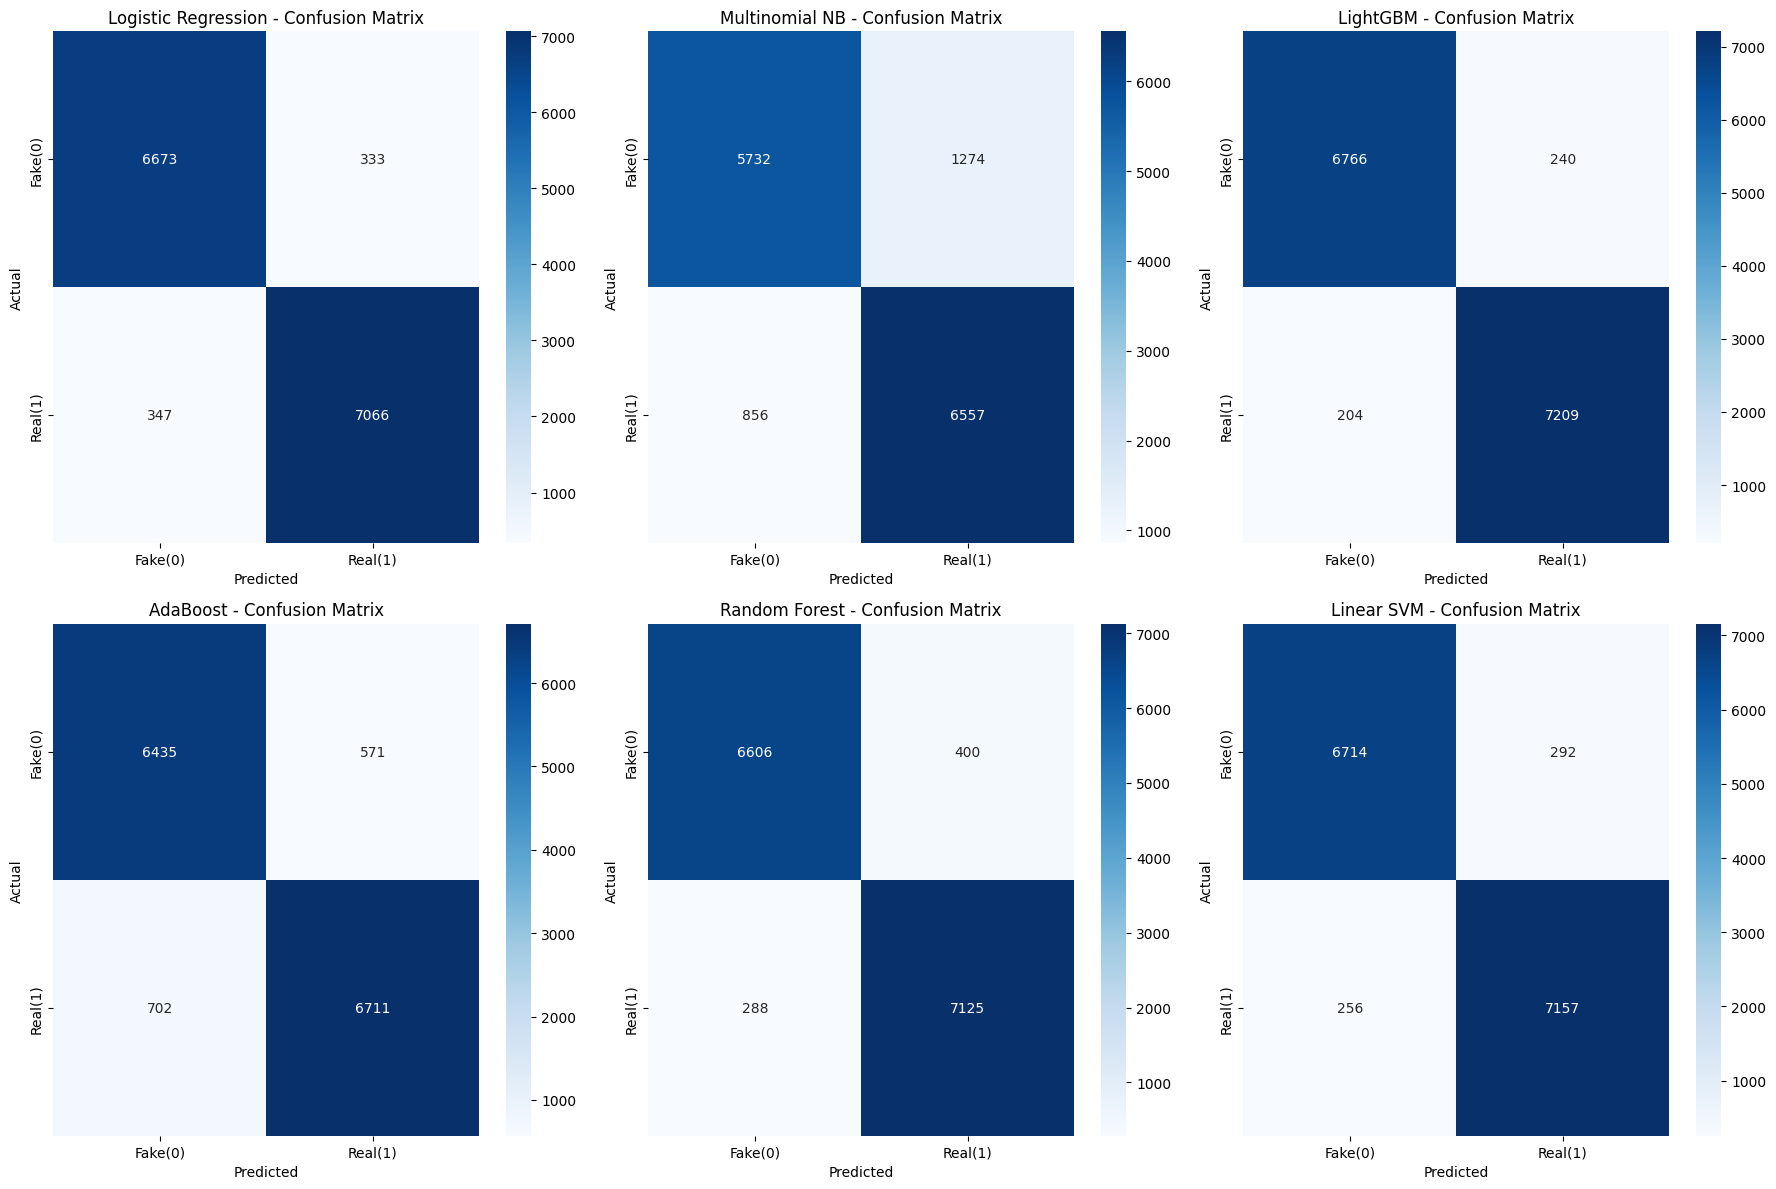

In [ ]:
# Fit all models on the entire training set to create the confusion matrix
models = {
    'Logistic Regression': lr_model,
    'Multinomial NB': nb_model,
    'LightGBM': lgb_model,
    'AdaBoost': ada_model,
    'Random Forest': rf_model,
    'Linear SVM': svm_model
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

print("Generating confusion matrices...")
for i, (model_name, model) in enumerate(models.items()):
    print(f"Processing {model_name}...")
    model.fit(X_train_final, y_train)

    y_pred = model.predict(X_test_final)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"{model_name} - Confusion Matrix")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

    axes[i].set_xticklabels(["Fake(0)", "Real(1)"])
    axes[i].set_yticklabels(["Fake(0)", "Real(1)"])

plt.tight_layout()
plt.show()


In [ ]:
directory = "saved_models/"
os.makedirs(directory, exist_ok=True)
for model_name, model in models.items():
    name = model_name.replace(" ", "_").lower()
    path = f"{directory}{name}.pkl"
    joblib.dump(model, path)

joblib.dump(tfidf, f"{directory}tfidf_vectorizer.pkl")
joblib.dump(scaler, f"{directory}stylometric_scaler.pkl")

['saved_models/stylometric_scaler.pkl']

In [ ]:
best_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1)

# Train on the entire training set (the 80% of the original data)
best_model.fit(X_train_final, y_train)

y_pred = best_model.predict(X_test_final)
y_pred_proba = best_model.predict_proba(X_test_final)[:, 1]

print("=== FINAL REPORT ON TEST SET ===")
print(classification_report(y_test, y_pred, digits=4))
print(f"Final AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Training final model on X_train_final...
[LightGBM] [Info] Number of positive: 29654, number of negative: 28022
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.232900 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1581738
[LightGBM] [Info] Number of data points in the train set: 57676, number of used features: 10002
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.514148 -> initscore=0.056607
[LightGBM] [Info] Start training from score 0.056607
Valuation on Test Set in progress...



c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


=== FINAL REPORT ON TEST SET ===
              precision    recall  f1-score   support

           0     0.9707    0.9657    0.9682      7006
           1     0.9678    0.9725    0.9701      7413

    accuracy                         0.9692     14419
   macro avg     0.9693    0.9691    0.9692     14419
weighted avg     0.9692    0.9692    0.9692     14419

Final AUC-ROC: 0.9955


c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


### SHAP values

In [ ]:
text_feature_names = tfidf.get_feature_names_out()

stylo_feature_names = ['text_length', 'text_exclamation_ratio', 'title_uppercase_ratio', 'title_exclamation_ratio', 'spelling_errors_ratio']

all_feature_names = list(text_feature_names) + stylo_feature_names

print(f"Number of feature extracted: {len(all_feature_names)}") # Should be 10005 (10000 from TF-IDF + 5 stilometriche)

Number of feature extracted: 10005


In [ ]:
best_model = joblib.load('saved_models/lightgbm.pkl')

In [ ]:
shap.initjs()

# Take a sample from the Test Set (e.g., the first 1000 rows) to avoid crashing the PC
X_test_sample = X_test_final.tocsr()[:1000].toarray() # Convert the sparse matrix to dense for SHAP

# Initialize the SHAP Explainer by passing our trained LightGBM model
print("Calculating SHAP values... (this might take a minute)")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sample)

# Note: For LightGBM, shap_values is a list with two arrays (one for each class). 
# We will use the one for the positive class (index 1) for our summary plot.
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

Calculating SHAP values... (this might take a minute)


c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


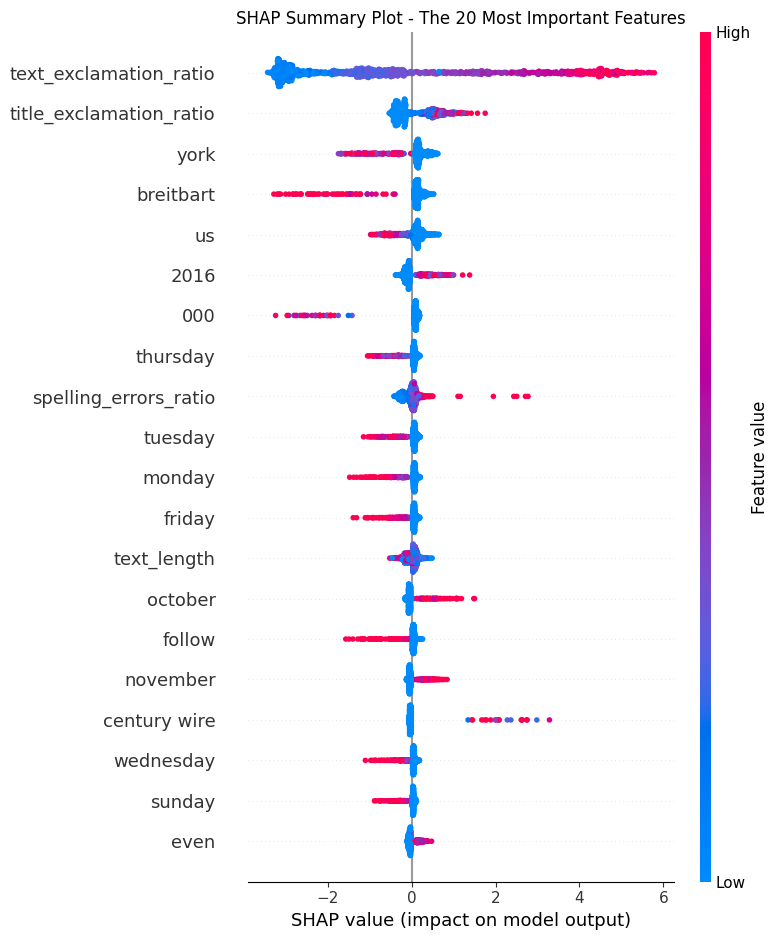

In [45]:
# Summary Plot with the top 20 most important features
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot - The 20 Most Important Features")
shap.summary_plot(
    shap_values_to_plot, 
    X_test_sample, 
    feature_names=all_feature_names, 
    max_display=20 # Top 20 features
)

Each point is an article in the test set.

Color indicate the value of the feature (red = high, blue = low).

X-axis indicate how that feature push the prediction (to the right = push towards "Fake", to the left = push towards "Real").

CURIOSITY: The first interesting thing is that the feature "text_exclamation_ratio" seems to push the prediction towards "Fake" (positive SHAP values) when it is high (red points), and towards "Real" (negative SHAP values) when it is low (blue points). This could indicate that articles with a high ratio of exclamation marks in the text are more likely to be fake news, while those with a low ratio are more likely to be real news.

Another one is that days of the week seems to push the prediction towards "Real" (negative SHAP values) when it is high (red points), and remain indifferent (0) when it is low (blue points). This could indicate that articles with a day written on it are more likely to be real.

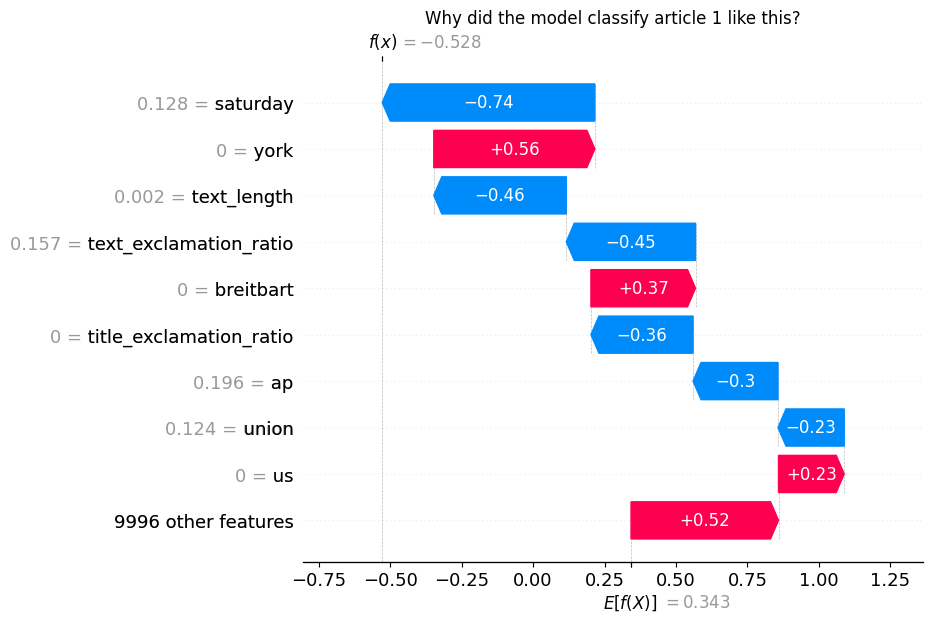

In [ ]:
article_index = 1

exp = shap.Explanation(
    values=shap_values_to_plot[article_index], 
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value, 
    data=X_test_sample[article_index], 
    feature_names=all_feature_names
)

# Generate a Waterfall Plot for the selected article
plt.figure(figsize=(8, 5))
plt.title(f"Why did the model classify article {article_index} like this?")
shap.plots.waterfall(exp, max_display=10)

How to read the plot:
- On the bottom there is the expected value (the average model output over the training data, shown as a vertical gray line).
This is the baseline prediction of the model before seeing any features.
- Going up the model adds the contribution of each feature (the SHAP value) to the prediction for that specific article.
- Each feature's contribution is represented by a value and a color. The color is red if the feature push the prediction towards "Fake" and blue if it push towards "Real". The value indicates how much that feature is contributing to the final prediction for that article.
- At the top of the plot, you can see the final prediction for each article, which is the sum of the expected value and all the SHAP values for that article.
- The values on the left are the feature values in that specific article.

Generating Waterfall Plots for the first 10 articles...



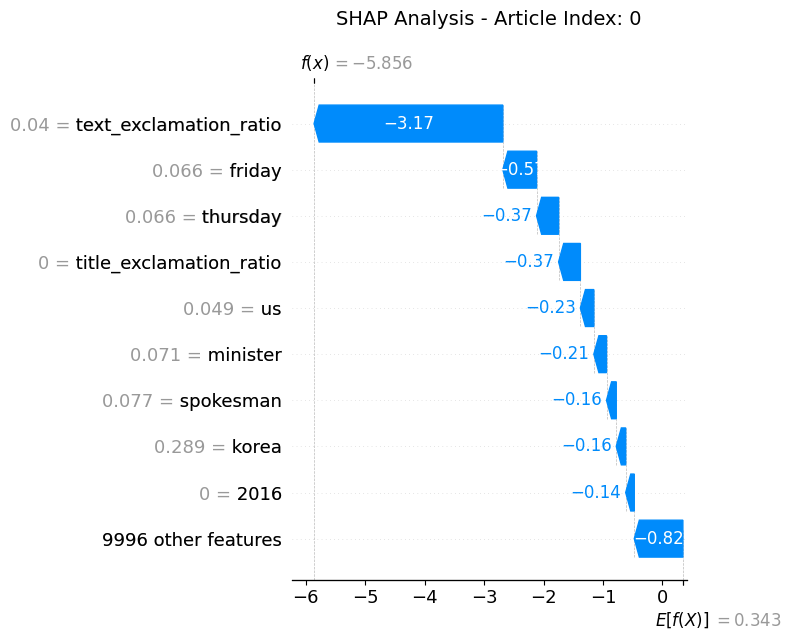

--------------------------------------------------------------------------------


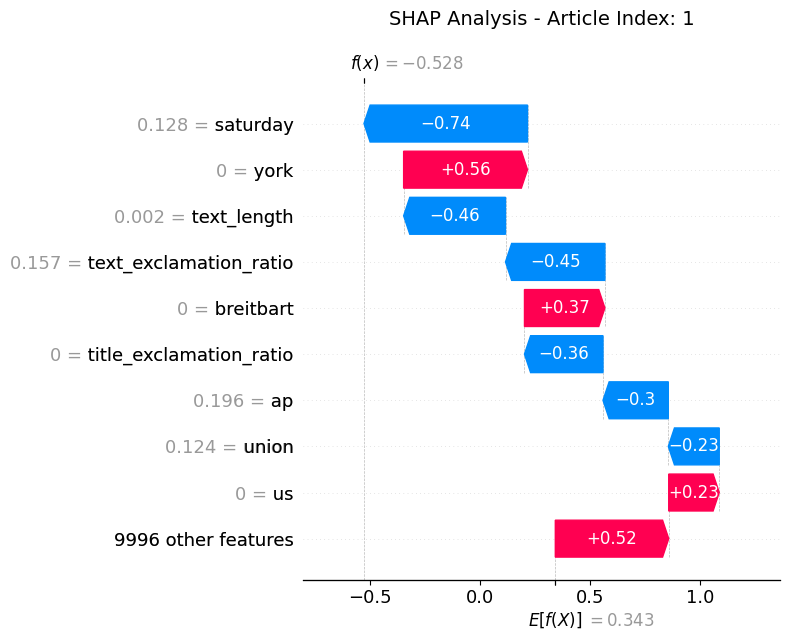

--------------------------------------------------------------------------------


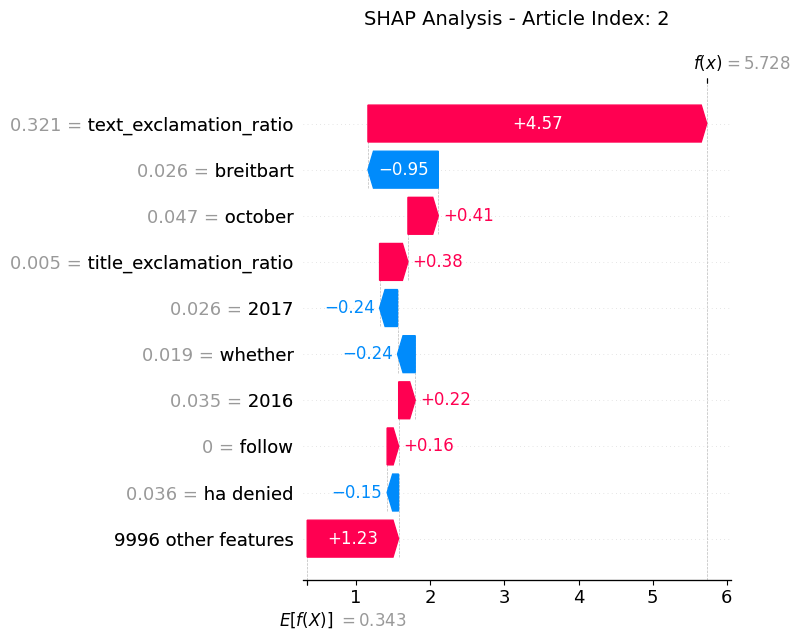

--------------------------------------------------------------------------------


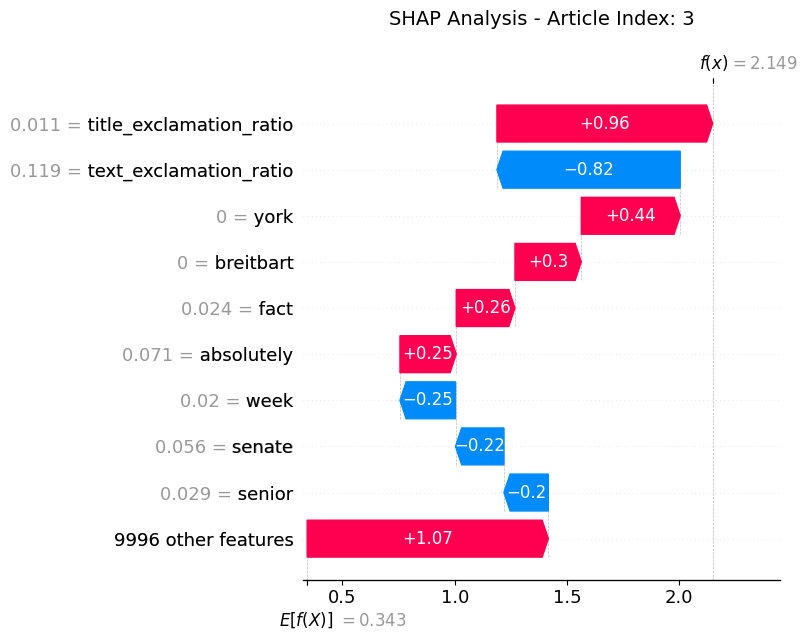

--------------------------------------------------------------------------------


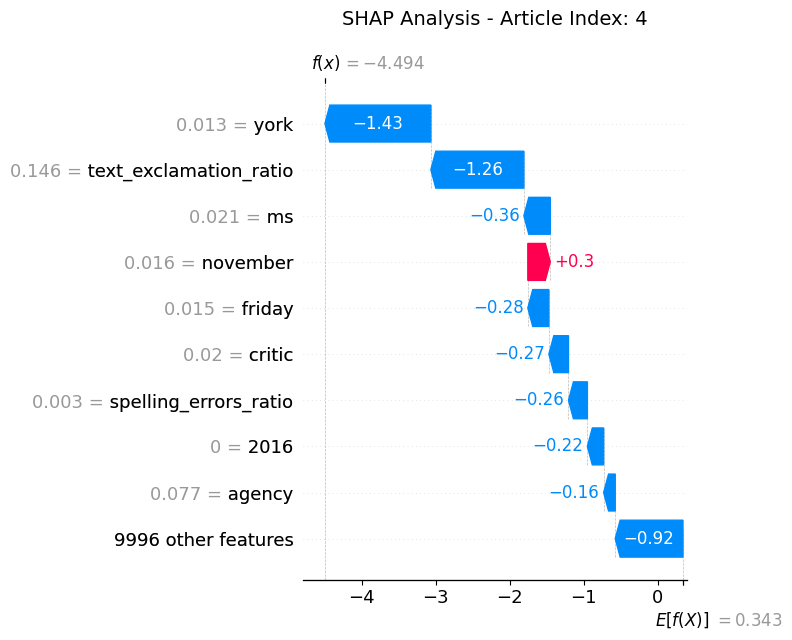

--------------------------------------------------------------------------------


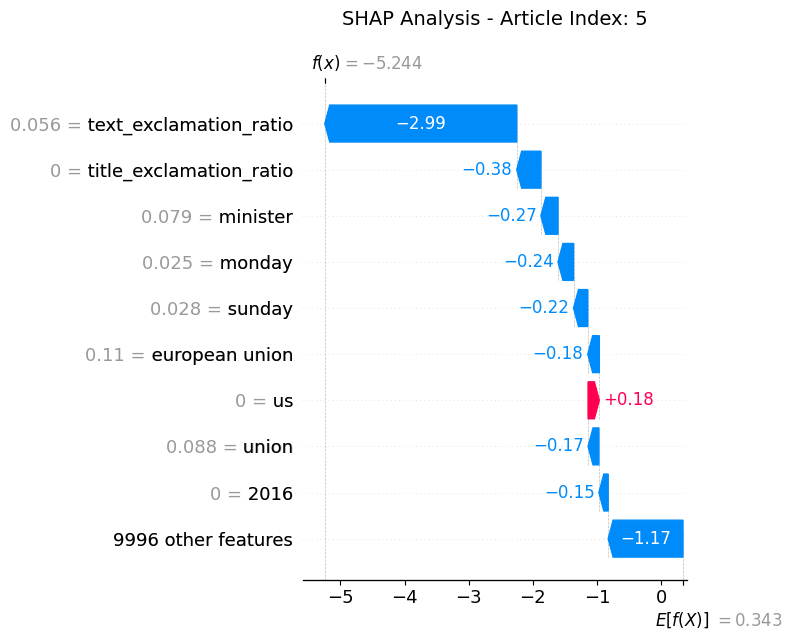

--------------------------------------------------------------------------------


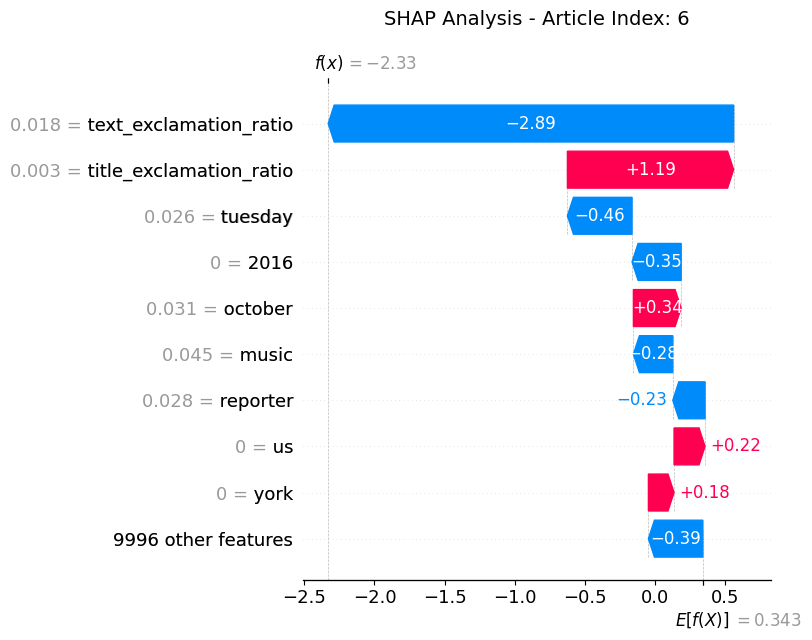

--------------------------------------------------------------------------------


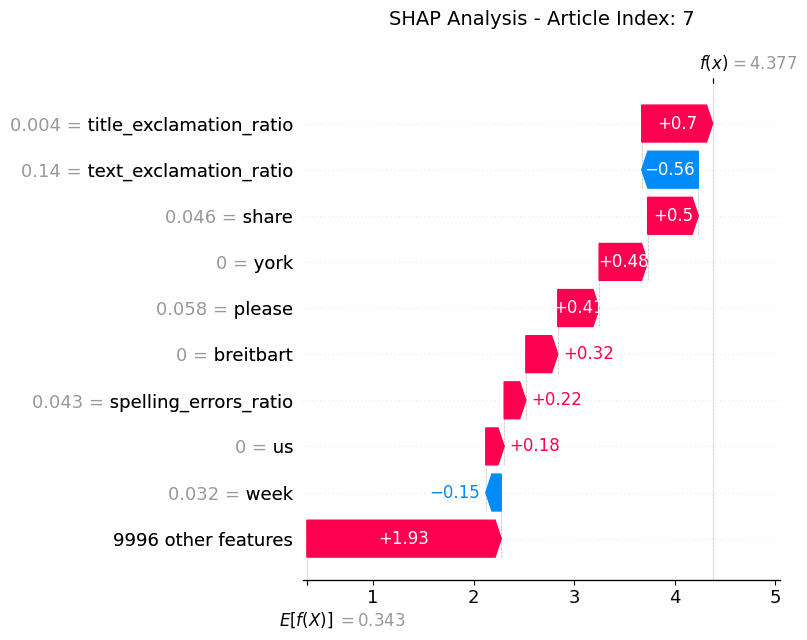

--------------------------------------------------------------------------------


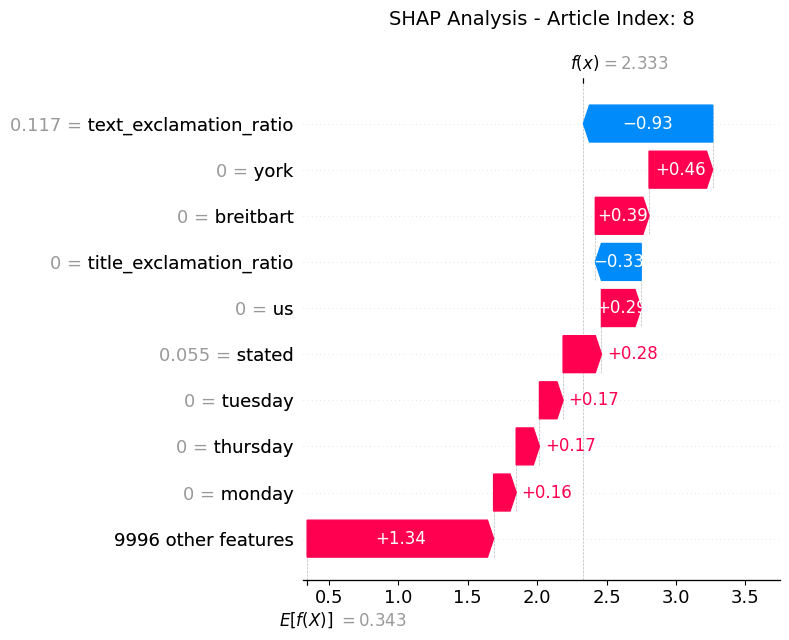

--------------------------------------------------------------------------------


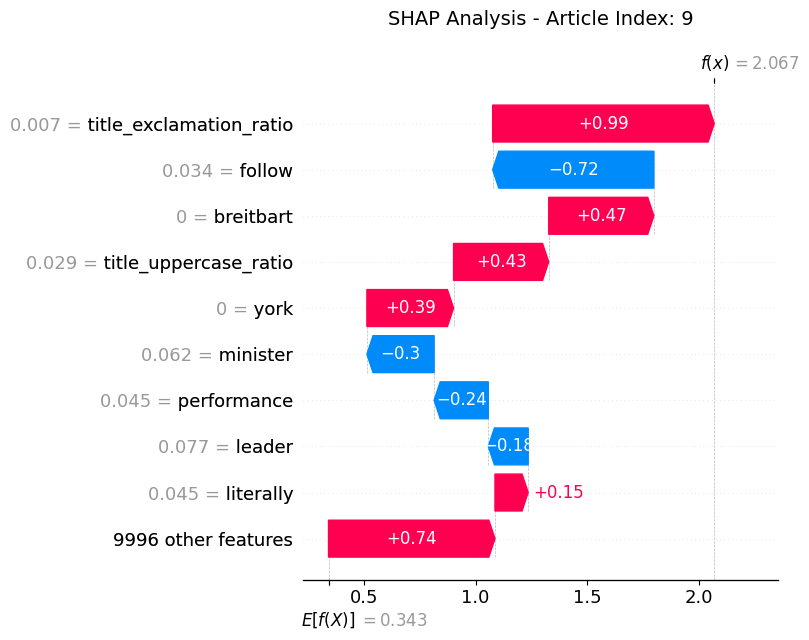

--------------------------------------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt
import shap

num_articles = 10

print(f"Generating Waterfall Plots for the first {num_articles} articles...\n")

for article_index in range(num_articles):
    exp = shap.Explanation(
        values=shap_values_to_plot[article_index], 
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value, 
        data=X_test_sample[article_index], 
        feature_names=all_feature_names
    )
    plt.figure(figsize=(8, 5))
    
    shap.plots.waterfall(exp, max_display=10, show=False)
    
    plt.title(f"SHAP Analysis - Article Index: {article_index}", fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()
    
    print("-" * 80)

### Hyperparameter Tuning
In this section, we will perform hyperparameter tuning for the best-performing model identified in the previous step. We will use GridSearchCV to search for the optimal hyperparameters that maximize the model's performance on the training data.

In [93]:
# load saved matrices
X_train_final = sparse.load_npz("saved_matrices/X_train_final.npz")
X_test_final = sparse.load_npz("saved_matrices/X_test_final.npz")
y_train = np.load("saved_matrices/y_train.npy")
y_test = np.load("saved_matrices/y_test.npy")


In [ ]:
param_grid = {
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50],
    'max_depth': [-1, 10],
    'n_estimators': [100, 200],
    'colsample_bytree': [0.8, 1.0],
    'subsample': [0.8, 1.0]
}

lgb_base = lgb.LGBMClassifier(random_state=42, n_jobs=-1)

cv_stratified = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=lgb_base,
    param_grid=param_grid,
    scoring='f1',
    cv=cv_stratified,
    n_jobs=-1,
    verbose=2
)

print("Starting Grid Search for LightGBM hyperparameters...")
grid_search.fit(X_train_final, y_train)
print("Best Hyperparameters found:")
print(grid_search.best_params_)

# save grid search results
grid_results_df = pd.DataFrame(grid_search.cv_results_)
grid_results_df.to_csv("results/lightgbm_grid_search_results.csv", index=False)

Starting Grid Search for LightGBM hyperparameters...
Fitting 3 folds for each of 64 candidates, totalling 192 fits
[LightGBM] [Info] Number of positive: 29654, number of negative: 28022
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.088623 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1581738
[LightGBM] [Info] Number of data points in the train set: 57676, number of used features: 10002
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.514148 -> initscore=0.056607
[LightGBM] [Info] Start training from score 0.056607
Best Hyperparameters found:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 50, 'subsample': 0.8}


### Final Model Evaluation
After tuning the hyperparameters, we will evaluate the final model on the test set to assess its performance. We will calculate various metrics such as accuracy, precision, recall, and F1-score to understand how well the model is performing in classifying fake and real news articles.

In [ ]:
final_tuned_lgbm = lgb.LGBMClassifier(
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=-1,
    n_estimators=200,
    num_leaves=50,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

final_tuned_lgbm.fit(X_train_final, y_train)

y_pred = final_tuned_lgbm.predict(X_test_final)
y_pred_proba = final_tuned_lgbm.predict_proba(X_test_final)[:, 1]
print(classification_report(y_test, y_pred, digits=4))

print(f"Final AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")

joblib.dump(final_tuned_lgbm, 'saved_models/lightgbm_tuned.pkl')



[LightGBM] [Info] Number of positive: 29654, number of negative: 28022
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.353292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1581738
[LightGBM] [Info] Number of data points in the train set: 57676, number of used features: 10002
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.514148 -> initscore=0.056607
[LightGBM] [Info] Start training from score 0.056607


c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


              precision    recall  f1-score   support

           0     0.9851    0.9729    0.9790      7006
           1     0.9747    0.9861    0.9804      7413

    accuracy                         0.9797     14419
   macro avg     0.9799    0.9795    0.9797     14419
weighted avg     0.9797    0.9797    0.9797     14419

Final AUC-ROC: 0.9976


['saved_models/lightgbm_tuned.pkl']

### Confusion Matrix

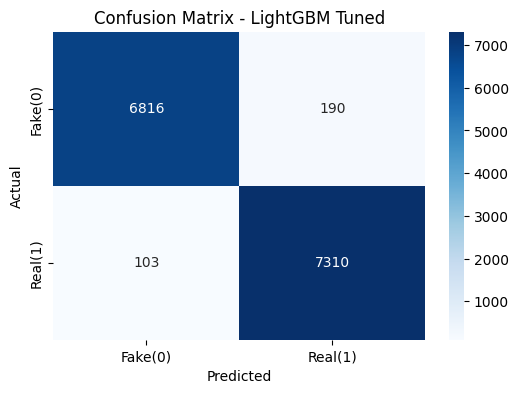

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - LightGBM Tuned")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ["Fake(0)", "Real(1)"])
plt.yticks([0.5, 1.5], ["Fake(0)", "Real(1)"])
plt.show()

### SHAP Values 

In [ ]:
tfidf = joblib.load('saved_models/tfidf_vectorizer.pkl')

text_feature_names = tfidf.get_feature_names_out()

stylo_feature_names = ['text_length', 'text_exclamation_ratio', 'title_uppercase_ratio', 'title_exclamation_ratio', 'spelling_errors_ratio']

all_feature_names = list(text_feature_names) + stylo_feature_names

print(f"Number of feature extracted: {len(all_feature_names)}")

Number of feature extracted: 10005


Calculating SHAP values...


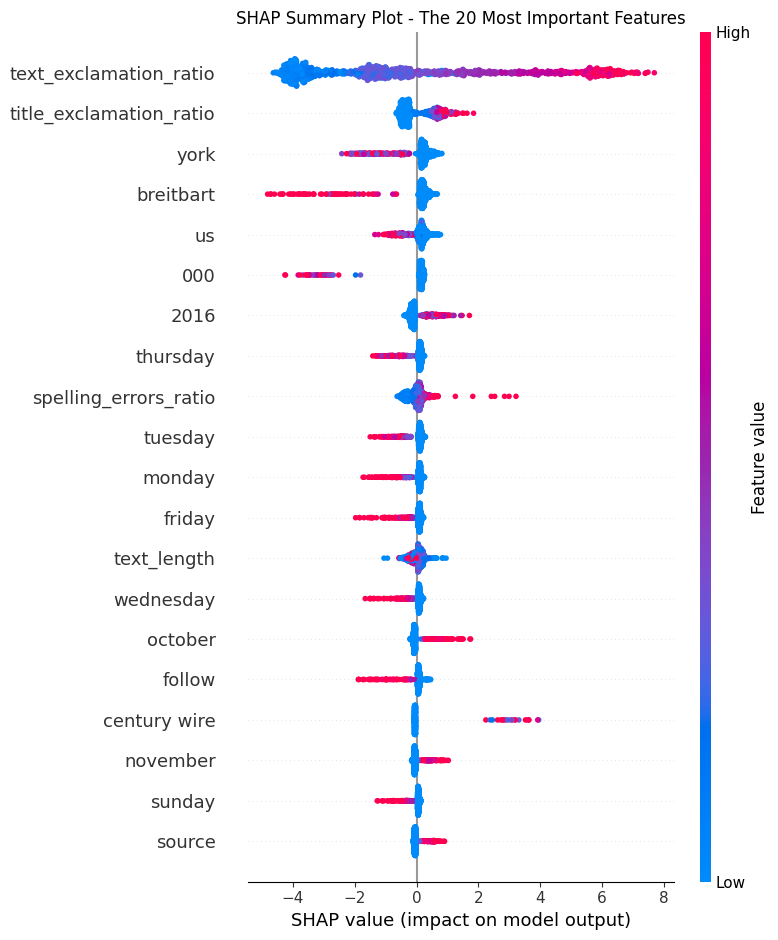

In [ ]:
shap.initjs()

X_test_sample = X_test_final.tocsr()[:1000].toarray()

print("Calculating SHAP values...")
explainer = shap.TreeExplainer(final_tuned_lgbm)
shap_values = explainer.shap_values(X_test_sample)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

# Summary Plot with the top 20 most important features
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot - The 20 Most Important Features")
shap.summary_plot(
    shap_values_to_plot, 
    X_test_sample, 
    feature_names=all_feature_names, 
    max_display=20 
)

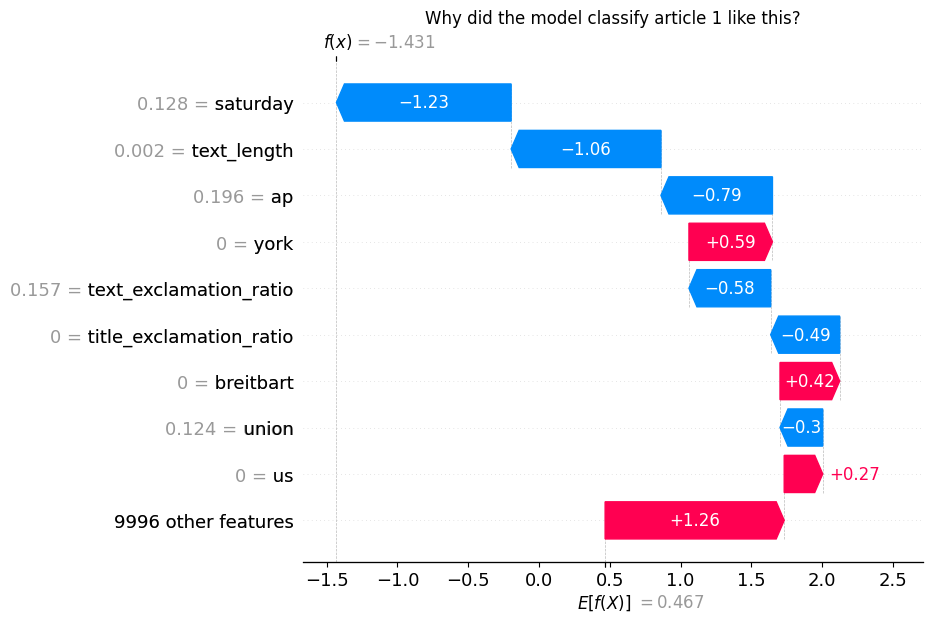

In [ ]:

article_index = 1

exp = shap.Explanation(
    values=shap_values_to_plot[article_index], 
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value, 
    data=X_test_sample[article_index], 
    feature_names=all_feature_names
)

plt.figure(figsize=(8, 5))
plt.title(f"Why did the model classify article {article_index} like this?")
shap.plots.waterfall(exp, max_display=10)